# Notebook 12 — Time Series Analysis: a brain rhythm in EEG

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to the **Time Series** lecture. 

### By the end of this notebook you will be able to:
- Load a recording and its channel names, and build a time axis from the **sampling rate**.
- Select and visualise **segments** of a multi-channel time series.
- Remove fast noise from a signal by **smoothing** (a convolution).
- Measure the periodicity of a rhythm with the **autocorrelation**.
- **Align** signals to an event, and understand when averaging is (and is less) appropriate.
- Compare channels with **cross-correlation** to see which regions share a rhythm.

### Scientific context reminder: alpha oscillations

As you could already see in the previous coding session, a slow, typical rhythm appears over the posterior regions of the brain when someone closes their eyes. Today, instead of using principal component analysis, we will use typical time series analyses to dive deeper into our eyes-open/eyes-closed EEG dataset. We will load one person's EEG recording, clean it, and find back our rhythm using only tools that work in **time**. We will also see how time series data can contain both rhythmic, continuous oscillations of the signal as well as sparse, occasional events. Both information can be retrieved and interpreted using the tools we will focus on in this course.

*Dataset:* EEG Alpha Waves dataset (alphawaves.npz, from https://zenodo.org/records/2348892)

### Table of contents
1. [Loading the tools](#sec-1) 
2. [Finding the data](#sec-2)
3. [Channel names](#sec-3)
4. [Load a subject](#sec-4)
5. [Sampling rate](#sec-5)
6. [The events](#sec-6)
7. [The whole recording](#sec-7)
8. [Zoom: closed vs open](#sec-8)
9. [Smoothing](#sec-9)
10. [Autocorrelation](#sec-10)
11. [Aligning to an event](#sec-11)
12. [Averaging the autocorrelation](#sec-12)
13. [Cross-correlation across electrodes](#sec-13)

<a id="sec-1"></a>
## 1. Loading the tools
As usual, we import the scientific stack under the usual short aliases.

In [43]:
import numpy as np                 # numerical arrays and math
import pandas as pd                 # tables (DataFrames)
import matplotlib.pyplot as plt     # plotting
from cycler import cycler

# Configuring the plots style (feel free to edit)
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83"]),  # C0 blue, C1 orange, C2 purple
})

<a id="sec-2"></a>
## 2. Finding the data
All the recordings live in a single file, `alphawaves.npz`. Change `DATA_DIR` to the folder where
you saved it. You can pick any subject from 0 to 19 — a nice way to appreciate biological
variability once the notebook runs.

In [44]:
from pathlib import Path

# locate the course data folder, wherever the notebook is opened from
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
DATA_DIR = ROOT / "data"

SUBJECT = 17    # choose a subject from 0 to 19

<a id="sec-3"></a>
## 3. Open the file and read the channel names
The file is an archive holding several named arrays; `archive.files` lists them. Among them are the
EEG signals themselves and the list of **channel names** (the electrodes), which we read so we can
refer to a channel by name (e.g. `"O1"`). The list comprehension below (see 'list comprehension' in
Notebook 1, §7.3) turns the stored names into a clean Python list.

In [45]:
archive = np.load(f"{DATA_DIR}/alphawaves.npz")
print("arrays in the file:", archive.files)

ch_names = [str(c) for c in archive["ch_names"]]
print("channels:", ch_names)

arrays in the file: ['X', 'condition', 'subject', 'block', 'onset_s', 'times', 'ch_names', 'ch_xy', 'sfreq']
channels: ['FP1', 'FP2', 'FC5', 'FC6', 'FZ', 'T7', 'CZ', 'T8', 'P7', 'P3', 'PZ', 'P4', 'P8', 'O1', 'Oz', 'O2']


<a id="sec-4"></a>
## 4. Assemble one subject's recording into a table
Each subject's recording is split into successive **blocks** of about ten seconds, each one either
eyes-closed or eyes-open. The array `archive["X"]` holds them arranged as *[block, channel, time]*.
We keep this subject's blocks, put them in order, join them end to end into one continuous recording,
and store it as a **table** (a DataFrame, as in Notebook 2) with one column per channel.

In [46]:
# keep this subject's blocks and put them in order
mine       = archive["subject"] == f"subject_{SUBJECT:02d}"
blocks     = archive["X"][mine]                 # [block, channel, time]
conditions = archive["condition"][mine]         # "eyes_closed" / "eyes_open" for each block
order      = np.argsort(archive["block"][mine])
blocks, conditions = blocks[order], conditions[order]

# join the blocks end to end -> one continuous recording, with channels as columns
recording = np.concatenate(blocks, axis=-1).T   # shape: (time, channels)
data = pd.DataFrame(recording, columns=ch_names)
data.head()

,FP1,FP2,FC5,FC6,FZ,T7,CZ,T8,P7,P3,PZ,P4,P8,O1,Oz,O2
0,-3705.003174,-4763.691406,-492.417480,8958.591797,-508.643341,9452.827148,12413.809570,-4529.226074,3678.683350,5358.708984,12326.506836,5479.036133,-755.883118,12937.574219,1116.237305,2099.094727
1,-3702.388184,-4747.538574,-475.367126,8960.168945,-507.996033,9456.005859,12410.679688,-4539.481445,3674.435303,5350.251465,12321.540039,5471.094727,-761.175903,12928.974609,1109.020386,2089.543457
2,-3701.119141,-4749.037109,-472.142731,8958.694336,-510.581055,9446.621094,12405.308594,-4545.267578,3655.555908,5334.594238,12315.388672,5461.761230,-769.629944,12894.983398,1080.699219,2065.793945
3,-3689.664062,-4751.295410,-453.378387,8968.254883,-510.720062,9466.589844,12413.016602,-4545.028320,3672.661865,5339.536133,12312.265625,5455.208496,-786.186462,12901.084961,1078.191406,2063.013672
4,-3684.945068,-4744.338867,-456.924164,8975.046875,-503.385925,9473.716797,12417.553711,-4538.325684,3673.682617,5350.115234,12310.327148,5451.899902,-790.005737,12920.616211,1088.365356,2067.155273


<a id="sec-5"></a>
## 5. Get the sampling rate
The **sampling rate** is the number of samples recorded every second (in Hz). It is stored in the
file. From it we build a time axis running across the whole recording.

In [47]:
sampling_rate = float(archive["sfreq"])
time = np.arange(len(data)) / sampling_rate
print(f"sampling rate = {sampling_rate:.0f} Hz")

sampling rate = 256 Hz


<a id="sec-6"></a>
## 6. Find when the eyes were closed and open
Every block is labelled eyes-closed or eyes-open. Each block has the same length, so the position
where block number *k* begins is simply *k × (block length)*. We compute those positions, then keep
the closed ones and the open ones separately.

> **▶ Task 6.1 — Keep the closed and open block starts.**
> `block_starts` holds the sample position where each block begins, and `conditions` holds each
> block's label. Fill in the two lines that keep only the **closed** starts and only the **open**
> starts. *Hint:* use a **boolean mask** — `block_starts[conditions == "eyes_closed"]` keeps the
> positions where the label is `"eyes_closed"`. Keep the two `print` lines to check your answer.

In [56]:
block_len    = blocks.shape[-1]                 # number of samples in one block
block_starts = np.arange(len(blocks)) * block_len

# fill the line to define closed_starts, retrieving the block starts labelled "eyes_closed"
# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
closed_starts = block_starts[conditions == "eyes_closed"]   
# --- END SOLUTION

# fill the line to define open_starts, retrieving the block starts labelled "eyes_open"
# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
open_starts   = block_starts[conditions == "eyes_open"]     
# --- END SOLUTION

# --- keep the two lines below to check your result ---
print("eyes-closed blocks start at (s):", np.round(time[closed_starts], 1))
print("eyes-open   blocks start at (s):", np.round(time[open_starts], 1))

eyes-closed blocks start at (s): [ 0. 20. 40. 60. 80.]
eyes-open   blocks start at (s): [10. 30. 50. 70. 90.]


<a id="sec-7"></a>
## 7. Look at one channel across the whole recording
We use `O1`, an electrode over the occipital lobe (back of the head), where this rhythm is known to
be strongest. Blue lines mark the start of each eyes-closed block, orange lines each eyes-open block.

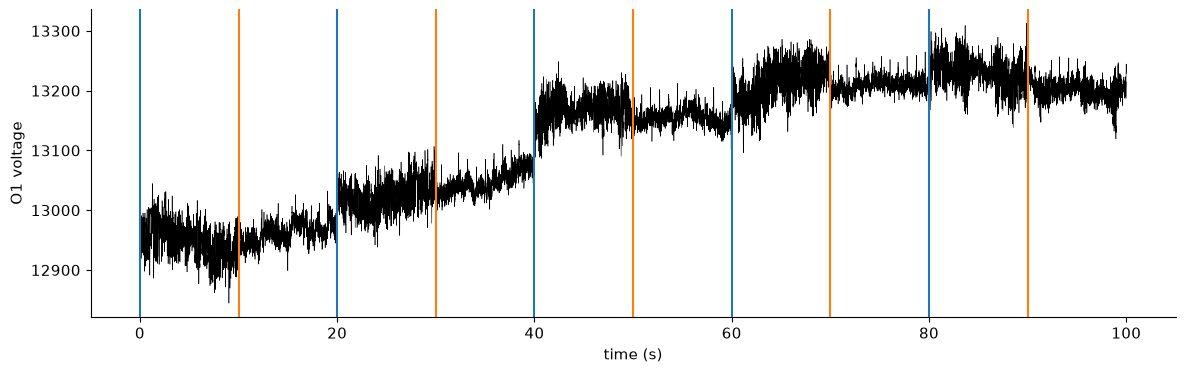

In [49]:
o1 = data["O1"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, o1, linewidth=0.4, color="black")
for s in closed_starts:
    ax.axvline(time[s], color="C0")
for s in open_starts:
    ax.axvline(time[s], color="C1")
ax.set_xlabel("time (s)"); ax.set_ylabel("O1 voltage")
plt.show()

<a id="sec-8"></a>
## 8. Zoom into the middle of one block, closed vs open
Can you see the oscillations while the eyes are closed? Probably not: two minutes are far too
dense to see rhythms that repeat ~10 times per second. Let's plot just **2 seconds** taken from
the middle of the first eyes-closed block and the first eyes-open block, side by side. We slice
only to *look* — the data itself is untouched.

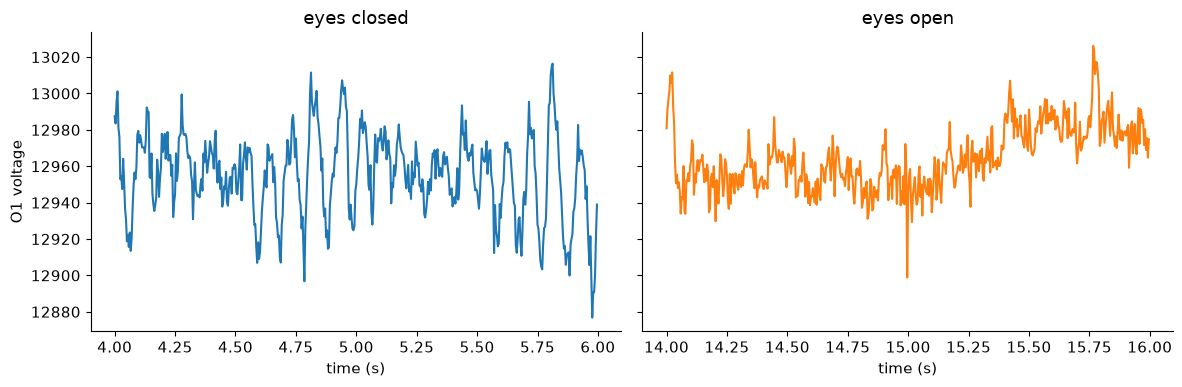

In [50]:
look = int(2 * sampling_rate)                     # 2 seconds, in samples
c0 = closed_starts[0] + int(4 * sampling_rate)   # ~middle of the first closed block
o0 = open_starts[0]   + int(4 * sampling_rate)   # ~middle of the first open block

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(time[c0:c0+look], o1[c0:c0+look], color="C0"); axes[0].set_title("eyes closed")
axes[1].plot(time[o0:o0+look], o1[o0:o0+look], color="C1"); axes[1].set_title("eyes open")
for a in axes: a.set_xlabel("time (s)")
axes[0].set_ylabel("O1 voltage")
plt.tight_layout(); plt.show()

<a id="sec-9"></a>
## 9. Smooth the recording to remove the fast noise
The oscillation we are looking for may still be hard to visualize due to very fast, low-amplitude fluctuations. That fast buzz is electrical noise from the mains power, not the brain. A standard way to remove
fast noise from a time series is **smoothing**: replacing each point with the average of its
neighbours. Sliding an average along a signal is a **convolution**; averaging flattens anything
faster than the window, so the buzz disappears while the slow wave stays.

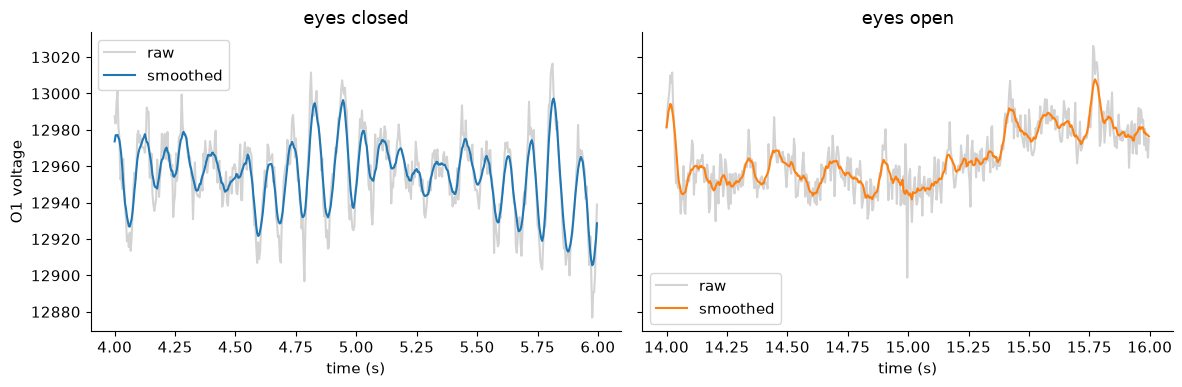

In [51]:
window = 10                                                       # average over 10 samples
o1_smooth = np.convolve(o1, np.ones(window) / window, mode="same")   # smooth the whole recording

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(time[c0:c0+look], o1[c0:c0+look], color="lightgray", label="raw")
axes[0].plot(time[c0:c0+look], o1_smooth[c0:c0+look], color="C0", label="smoothed")
axes[0].set_title("eyes closed"); axes[0].legend()
axes[1].plot(time[o0:o0+look], o1[o0:o0+look], color="lightgray", label="raw")
axes[1].plot(time[o0:o0+look], o1_smooth[o0:o0+look], color="C1", label="smoothed")
axes[1].set_title("eyes open"); axes[1].legend()
for a in axes: a.set_xlabel("time (s)")
axes[0].set_ylabel("O1 voltage")
plt.tight_layout(); plt.show()

> **▶ Task 9.1 — Choosing the window.**
> The window size controls how much we smooth. Re-run the smoothing with a **larger** window
> (e.g. 50) and a **smaller** one (e.g. 3), plotting the eyes-closed segment each time. What
> happens to the slow rhythm when the window gets too large? Convolution can reveal the signal by
> dissipating the noise, but too wide a window also erases the information we care about.

<a id="sec-10"></a>
## 10. Measure the rhythm with autocorrelation
The **autocorrelation** compares the signal with a delayed copy of itself. If a rhythm is
present, the signal lines up with itself once per cycle, giving evenly spaced peaks.

Because we will compute it several times, we write a small **function** for it.

In [52]:
def autocorrelation(x):
    """Return the normalised autocorrelation of x, for delays from 0 upward."""
    x = x - x.mean()                       # centre the signal on zero
    ac = np.correlate(x, x, mode="full")   # correlation at every delay
    ac = ac[ac.size // 2:]                 # keep delays >= 0
    return ac / ac[0]                      # scale so that delay 0 equals 1

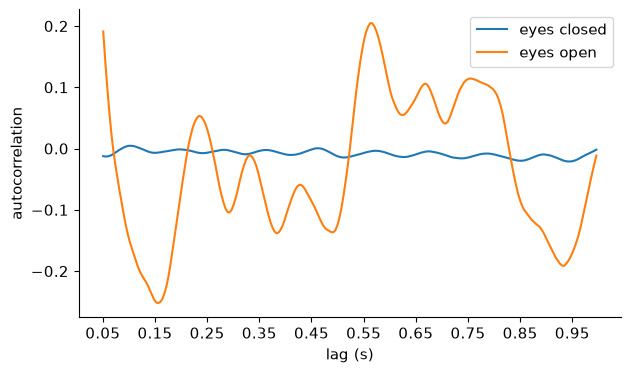

In [53]:
o1_smooth = np.convolve(o1, np.ones(10) / 10, mode="same")   # smooth the whole recording again
n = int(1 * sampling_rate)                 # use 1 second of each condition
ac_closed = autocorrelation(o1_smooth[closed_starts[0] : closed_starts[0] + n])
ac_open   = autocorrelation(o1_smooth[open_starts[0]   : open_starts[0]   + n])
lag_seconds = np.arange(ac_closed.size) / sampling_rate

time_cut = .05
mask = np.where(lag_seconds > time_cut)
ac_closed = ac_closed[mask]
ac_open = ac_open[mask]
lag_seconds = lag_seconds[mask]

fig, ax = plt.subplots()
ax.plot(lag_seconds, ac_closed, color="C0", label="eyes closed")
ax.plot(lag_seconds, ac_open,   color="C1", label="eyes open")
ax.set_xlabel("lag (s)"); ax.set_ylabel("autocorrelation")
ax.set_xticks(np.arange(time_cut, lag_seconds[-1], 0.1)); ax.legend()
plt.show()

> **▶ Task 10.1 — From a delay to a frequency.**
> The distance between two autocorrelation peaks is the **period** of the rhythm (in seconds),
> and its frequency in hertz is `1 / period`. Find the first peak of the eyes-closed
> autocorrelation *after* a delay of 50 ms, and print the corresponding frequency.
> *Hint:* build a boolean mask on `lag_seconds`, then use `np.argmax` on `ac_closed` inside it.

In [57]:
# TODO 10.1 — find the rhythm's frequency off the autocorrelation
# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
search = (lag_seconds > 0.05)         
peak_lag = lag_seconds[search][np.argmax(ac_closed[search])]
print(f"first peak at {peak_lag*1000:.0f} ms  ->  {1/peak_lag:.1f} Hz") 
# --- END SOLUTION

first peak at 102 ms  ->  9.8 Hz


<a id="sec-11"></a>
## 11. Aligning the signals to the eyes-closed event
Closing the eyes happens at a known moment, so a natural idea is to line up all five eyes-closed
blocks on their cue and **average** the signal. We take 1 second before and after each cue, and
subtract the pre-cue level (a *baseline correction*) so the blocks are comparable.

> **Task 11.1 — Cut the signal into epochs around each cue.** We want to line up the recording on the "close eyes" moments and average across them. To do that
> we cut out a short window **— an epoch —** around every cue. The setup is already written for you:
> pre and post are the numbers of samples for the 1 second before and the 1 second after a cue,
> and tau is the matching time axis of one epoch, running from −1 s to +1 s with 0 at the cue
(we use it only as the x-axis when plotting). The for loop walks through closed_starts, so on
each turn the variable s holds the sample position of one cue. (A first line that skips the very
first block — which has nothing before it — is already provided.)
>
> Your job is the two lines inside the loop:
>
> **1. Extract the epoch.** Using square-bracket slicing on o1_smooth, take the window that starts
> pre samples before s and ends post samples after it (i.e. from s - pre to s + post).
> Store it in epoch.
>
> **2. Baseline-correct it.** Subtract from epoch the average voltage measured before the cue, so
> all epochs start from the same level. The pre-cue part is the first pre samples of the epoch
>(epoch[:pre]), and you get its average with .mean().
>
> The line below (o1_epochs.append(epoch)) then collects each finished epoch into the list. Once the
loop is correct, the rest of the cell turns the list into an array and plots every epoch faintly with
their average on top.

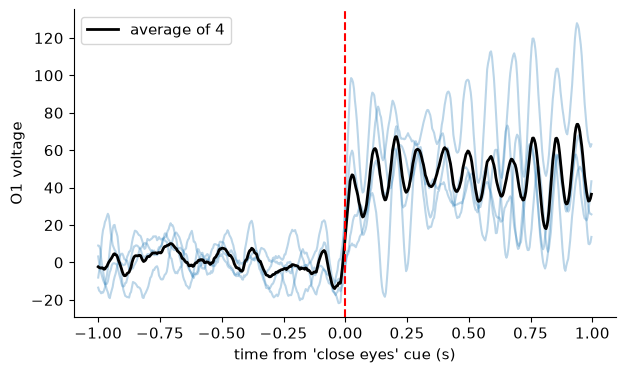

In [58]:
pre  = int(1 * sampling_rate)      # 1 second before the cue
post = int(1 * sampling_rate)      # 1 second after
tau  = np.arange(-pre, post) / sampling_rate

o1_epochs = []
for s in closed_starts:
    if s - pre < 0:                          # the very first block has nothing before it
        continue
    # --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
    epoch = o1_smooth[s-pre : s+post]        
    epoch = epoch - epoch[:pre].mean()       
    # --- END SOLUTION
    o1_epochs.append(epoch)
o1_epochs = np.array(o1_epochs)

fig, ax = plt.subplots()
for e in o1_epochs:
    ax.plot(tau, e, color="C0", alpha=0.3)
ax.plot(tau, o1_epochs.mean(0), color="black", linewidth=2, label=f"average of {len(o1_epochs)}")
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("time from 'close eyes' cue (s)"); ax.set_ylabel("O1 voltage"); ax.legend()
plt.show()

The single blocks are large, yet their average is much smaller — why would a real rhythm shrink
when we average it? Averaging keeps only what happens at the **same time *and* the same way** in
every block. This regular rhythm does not start at the same point of its cycle each time, so the
peaks and troughs fall on top of each other and may cancel each other. So averaging raw blocks after
lining them up is not always the right approach: it is perfect for a fixed response locked to the
event, but it hides a rhythm whose timing can drift. We need a measure that ignores *where* each
cycle starts.

<a id="sec-12"></a>
## 12. Average the rhythm itself, with autocorrelation
The autocorrelation enables to identify a regular rhythm *regardless of when each cycle begins*, so it survives
averaging while the noise still cancels. We reuse our `autocorrelation` function on every block
(a list comprehension over the cues), then average.

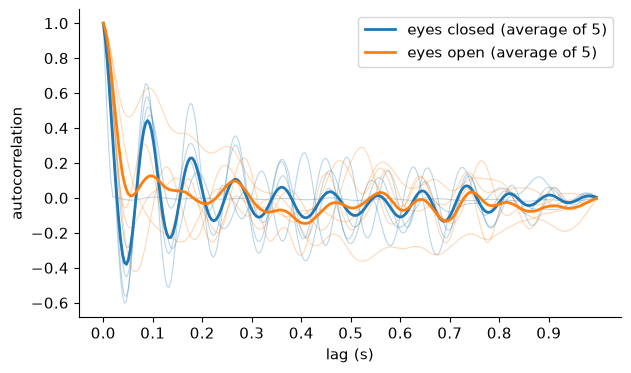

In [32]:
closed_acfs = [autocorrelation(o1_smooth[s : s + n]) for s in closed_starts]
open_acfs   = [autocorrelation(o1_smooth[s : s + n]) for s in open_starts]
closed_mean = np.mean(closed_acfs, axis=0)
open_mean   = np.mean(open_acfs, axis=0)
lag_seconds = np.arange(closed_mean.size) / sampling_rate

fig, ax = plt.subplots()

# single blocks, faint, behind the averages
for ac in closed_acfs:
    ax.plot(lag_seconds, ac, color="C0", alpha=0.3, linewidth=0.8)
for ac in open_acfs:
    ax.plot(lag_seconds, ac, color="C1", alpha=0.3, linewidth=0.8)

# the averages, bold, on top
ax.plot(lag_seconds, closed_mean, color="C0", linewidth=2, label="eyes closed (average of 5)")
ax.plot(lag_seconds, open_mean,   color="C1", linewidth=2, label="eyes open (average of 5)")

ax.set_xlabel("lag (s)"); ax.set_ylabel("autocorrelation")
ax.set_xticks(np.arange(0, lag_seconds[-1], 0.1)); ax.legend()
plt.show()

In [35]:
# Let's find the first peak of the averaged eyes-closed autocorrelation, after lag 0. This will give us an estimate of the overall frequency of the eyes-closed rhythm across blocks.
search = (lag_seconds > 0.05)                              # ignore the peak at lag 0 itself
peak_lag = lag_seconds[search][np.argmax(closed_mean[search])]
peak_frequency = 1 / peak_lag

print(f"first peak at {peak_lag*1000:.0f} ms  ->  {peak_frequency:.1f} Hz")

first peak at 90 ms  ->  11.1 Hz


<a id="sec-13"></a>
## 13. Which electrodes share the rhythm, and are they in step?
So far we only used `O1`. Does the rhythm appear elsewhere — for instance over the front of the
head? We compare every electrode with `O1` using **cross-correlation**, recording the *strongest
match* (how alike they are) and its *delay* (0 means they rise and fall together). A `for` loop
does all 16 channels; we smooth each one the same way as `O1` so the comparison is fair.

In [25]:
block = int(8 * sampling_rate)
block_start = closed_starts[0]
reference = o1_smooth[block_start : block_start + block]
reference = reference - reference.mean()
channels = ch_names                    # the 16 EEG channels

print(f"{'channel':8s}{'similarity':>12s}{'delay (ms)':>12s}")
for ch in channels:
    sig = np.convolve(data[ch].to_numpy(), np.ones(window) / window, mode="same")
    sig = sig[block_start : block_start + block]
    sig = sig - sig.mean()
    cc  = np.correlate(reference, sig, mode="full") / (np.std(reference) * np.std(sig) * len(reference))
    lag = np.arange(-(len(reference) - 1), len(reference)) / sampling_rate
    i = np.argmax(cc)
    print(f"{ch:8s}{cc[i]:>12.2f}{lag[i]*1000:>12.0f}")

channel   similarity  delay (ms)
FP1             0.05       -1203
FP2             0.05       -1211
FC5             0.21       -1195
FC6             0.99           0
FZ              0.11       -7621
T7              0.99           0
CZ              0.99           0
T8              0.02       -1219
P7              0.95           0
P3              0.99           0
PZ              1.00           0
P4              0.98           0
P8              0.13        -812
O1              1.00           0
Oz              0.71           0
O2              0.87           0


>**Task 13.1 — Plot a cross-correlation.**
The table above only gives the peak. Plot the whole cross-correlation for one channel of your
choice, so you can see it as a function of lag — just like the autocorrelation, but between two
different electrodes. Pick a close match (e.g. "O2") or a far one (e.g. "FP1"). Fill in the
two blanks:

>The cross-correlation cc — use the same formula as in the printout: np.correlate of
reference and sig with mode="full", divided by np.std(reference) * np.std(sig) * len(reference).
The lag axis, in seconds and centred on zero: np.correlate(..., "full") returns
2N-1 values whose lags run from -(N-1) to +(N-1), where N = len(reference). Build them
with np.arange(-(len(reference)-1), len(reference)) and divide by sampling_rate.

> Where is the peak of the curve? What does its position (near 0, or clearly shifted) tell you
about whether the two electrodes carry the same rhythm, and whether one leads the other?

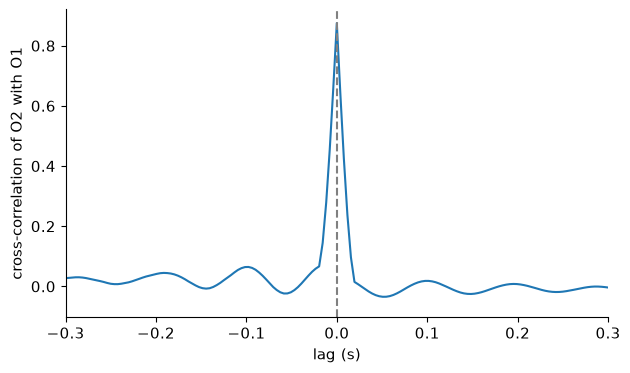

In [55]:
# TODO 13.1 — plot the cross-correlation of one channel with O1
ch = "O2"                       # try "O2" (a close match) or "FP1" (a far one)
sig = np.convolve(data[ch].to_numpy(), np.ones(window) / window, mode="same")
sig = sig[block_start : block_start + block]
sig = sig - sig.mean()
#fill the missing lines to define cc and lag
# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
cc  = np.correlate(reference, sig, mode="full") / (np.std(reference) * np.std(sig) * len(reference))   
lag = np.arange(-(len(reference) - 1), len(reference)) / sampling_rate                                 
# --- END SOLUTION
fig, ax = plt.subplots()
ax.plot(lag, cc, color="C0")
ax.axvline(0, color="gray", linestyle="--")
ax.set_xlim(-0.3, 0.3)
ax.set_xlabel("lag (s)"); ax.set_ylabel(f"cross-correlation of {ch} with O1")
plt.show()

## What we found
With only time-domain tools we cleaned the signal (smoothing away the electrical buzz), used the
**autocorrelation** to reveal a slow, regular rhythm that appears **when the eyes are closed**,
showed it is consistent across all five blocks, and learned that averaging raw blocks lined up on
a cue *cancels* a rhythm whose timing drifts (while it would keep a fixed, locked response). With
**cross-correlation** we saw the rhythm is shared by the **electrodes at the back of the head**,
rising and falling almost in step.

Reading the rhythm's speed off the autocorrelation by hand is clumsy, and it cannot easily say
*how strong* the rhythm is. **Next week** we meet the tool that measures the strength of every
frequency at once: the Fourier transform.